<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 5</b></center>    
<pre>    

# SVR

# Importing the libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Read World bank CSV

In [3]:
df = pd.read_csv('WorldBank.csv')

In [4]:
df.shape

(1440, 65)

In [5]:
df.sample(5)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
1236,India,IND,"Children out of school, female (% of female pr...",SE.PRM.UNER.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.573660e+00,2.083550e+00,1.432280e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,India,IND,"Net bilateral aid flows from DAC donors, Austr...",DC.DAC.AUSL.CD,NaN,NaN,NaN,NaN,NaN,9560000.42,...,2.433000e+07,2.777000e+07,1.868000e+07,12319999.69,4170000.076,4659999.847,6199999.809,6599999.905,NaN,NaN
1265,India,IND,Time to resolve insolvency (years),IC.ISV.DURS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.300000e+00,4.30,4.300,4.300,4.300,4.300,1.6,NaN
300,India,IND,Average number of visits or required meetings ...,IC.TAX.METG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.10,NaN,NaN,NaN,NaN,NaN,NaN
120,India,IND,CPIA equity of public resource use rating (1=l...,IQ.CPA.PRES.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000e+00,4.000000e+00,4.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [6]:
data = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


In [7]:
india = data[data['Country Name'] == 'India']
india

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [8]:
X = india.columns[4:].astype(int).values.reshape(-1, 1)

In [9]:
y = india.iloc[0, 4:].values
y

array([np.float64(56.49748004), np.float64(56.17753236),
       np.float64(55.80745463), np.float64(55.46166361),
       np.float64(55.24893881), np.float64(55.21135053),
       np.float64(55.09090078), np.float64(55.15534672),
       np.float64(55.34507283), np.float64(55.57014408),
       np.float64(55.78194745), np.float64(55.85676846),
       np.float64(55.95268174), np.float64(56.07247186),
       np.float64(56.23447551), np.float64(56.44405309),
       np.float64(56.49722595), np.float64(56.62068516),
       np.float64(56.78900152), np.float64(56.9691436),
       np.float64(57.1425581), np.float64(57.18105454),
       np.float64(57.22630775), np.float64(57.28875038),
       np.float64(57.39054366), np.float64(57.54142108),
       np.float64(57.55350984), np.float64(57.6545119),
       np.float64(57.81875323), np.float64(58.01501187),
       np.float64(58.22990246), np.float64(58.37403848),
       np.float64(58.5472698), np.float64(58.75605047),
       np.float64(59.012126), np.fl

# Plot scatter plot of Population ages 15-64 (% of total population)

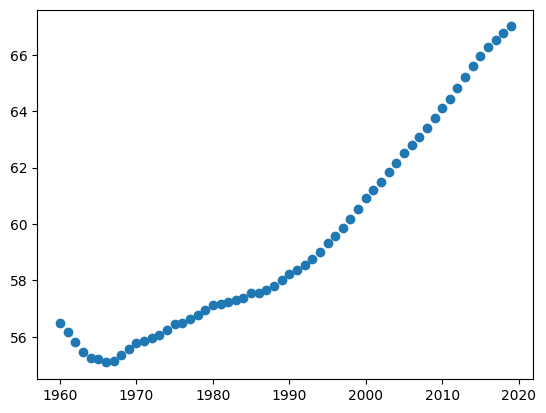

In [10]:
plt.scatter(X, y)
plt.show()

# Feature Scaling **(Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.reshape(-1, 1))

# Splitting the dataset into the Training set and Test set

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size = 0.2, random_state = 0
)

# Fitting SVR on 3 Different Kernel on dataset

In [15]:
svr_linear = SVR(kernel = 'linear')

svr_linear.fit(
    X_train, y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [16]:
svr_poly = SVR(kernel = 'poly', degree = 3)

svr_poly.fit(
    X_train, y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [17]:
svr_rbf = SVR(kernel = 'rbf')

svr_rbf.fit(
    X_train, y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [18]:
y_pred_linear = svr_linear.predict(X_test)

In [19]:
y_pred_poly = svr_poly.predict(X_test)

In [20]:
y_pred_rbf = svr_rbf.predict(X_test)

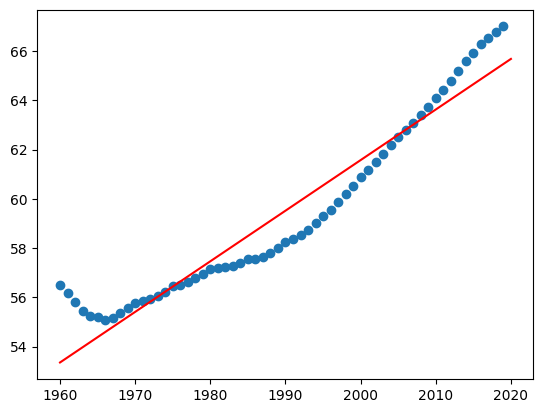

In [29]:
plt.scatter(X, y)

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_linear.predict(
            sc_X.transform(X)
        ).reshape(-1, 1)
    ),
    color = 'red'
)

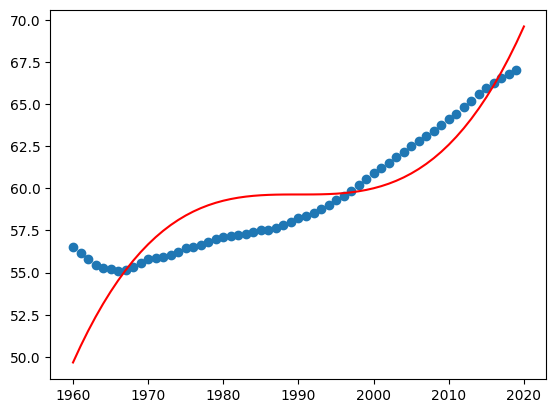

In [28]:
plt.scatter(X, y)

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_poly.predict(
            sc_X.transform(X)
        ).reshape(-1, 1)
    ),
    color = 'red'
)

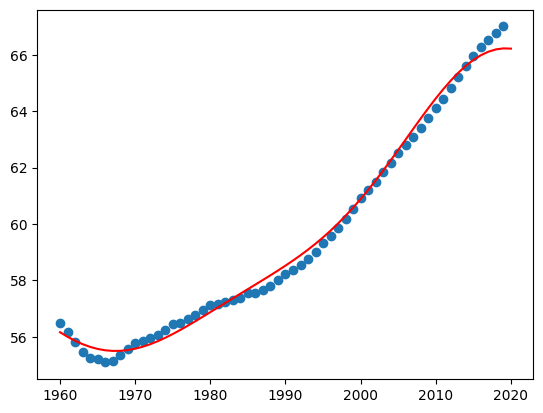

In [27]:
plt.scatter(X, y)

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_rbf.predict(
            sc_X.transform(X)
        ).reshape(-1, 1)
    ),
    color = 'red'
)

# Predict the x_test using 3 Kernel

In [34]:
svr_rbf.score(X_train, y_train)

0.9948606064238069

In [35]:
svr_linear.score(X_train, y_train)

0.9253069622433698

In [36]:
svr_poly.score(X_train, y_train)

0.7174981284190696

array([57.73445326, 59.30206118, 64.8451716 , 57.99812952, 55.96479236,
       56.12587167, 59.06485884, 64.91876466, 60.76906052, 57.24445561,
       55.93360816, 55.89821768, 58.29641078, 61.1088798 , 58.84682535,
       61.81299688, 63.81278461, 55.81527994])

# Visualising the  results

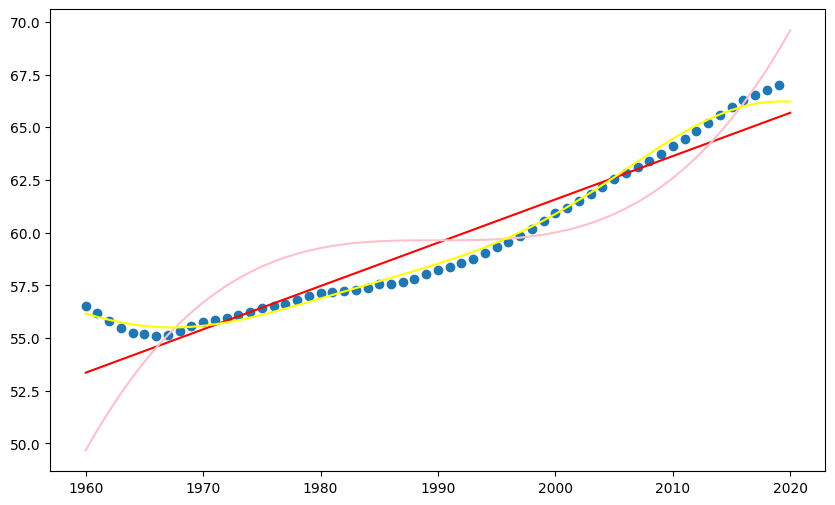

In [41]:
plt.figure(figsize = (10, 6))
plt.scatter(X, y)

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_linear.predict(
            sc_X.transform(X)
        ).reshape(-1, 1)
    ),
    color = 'red'
)

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_poly.predict(
            sc_X.transform(X)
        ).reshape(-1, 1)
    ),
    color = 'pink'
)

plt.plot(
    X,
    sc_y.inverse_transform(
        svr_rbf.predict(
            sc_X.transform(X)
        ).reshape(-1, 1)
    ),
    color = 'yellow'
)
plt.show()

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

In [56]:
year = int(input("Enter your year"))

answer = sc_X.transform(np.array(year).reshape(-1, 1))

pred_final_2d = sc_y.inverse_transform(pred_scaled.reshape(-1, 1))

final_prediction = pred_final_2d[0].item()
print(final_prediction)

Enter your year 2050


65.81611017085528
